# Notebook 02 — Construcción de Firmas Espacio-Temporales

**Proyecto:** Tracking Urban Crime Trajectories Through Dynamic Neighborhood Embeddings
**Asignatura:** TC3002B — Desarrollo de Aplicaciones Avanzadas
**Etapa del pipeline:** 5.2 — Construcción de representaciones espacio-temporales

**Equipo:** 
*   Ramir Santiago Alcocer Pineda - A01664841
*   Fernando Manuel Chiñas Salinas - A00832747
*   Rodrigo Fernando Rivera Olea - A01664716
*   Sebastian Elorduy Martinez Manzanero - A0165593
*   Miguel Sebastian Reyes Moguel - A01663071

---

  Este notebook documenta la segunda etapa del pipeline: la transformación de
  los 282,536 eventos delictivos limpios en una matriz de representaciones
  vectoriales densas por zona urbana y periodo anual. El territorio de la CDMX
  se discretiza en celdas hexagonales mediante la jerarquía H3 en resolución 8,
  equivalente a aproximadamente 0.74 km² por celda, y cada combinación de
  celda y año se representa mediante una firma de 22 dimensiones que captura
  cuatro aspectos complementarios del perfil delictivo: la composición por tipo
  de crimen, la distribución horaria, la distribución semanal y la intensidad
  relativa. Antes de construir las firmas se aplica un filtrado adaptativo en
  dos etapas que retiene únicamente las unidades con suficiente masa
  estadística para producir distribuciones estables, reduciendo las 9,120
  unidades crudas a 6,224 válidas sobre 748 celdas activas. La matriz
  resultante, normalizada con StandardScaler y almacenada en
  firmas_h3_8_anual.csv, constituye el input directo del autoencoder del
  Notebook 3. El resultado es una matriz de **6,224 filas × 22 columnas**: el dataset de entrada para el autoencoder de NB03.

## Introduccion

  individuales: cada fila describe un delito puntual con su tipo, ubicación y
  momento. En esa forma, los datos no tienen el formato necesario para modelar
  cómo evoluciona una zona urbana a lo largo del tiempo. Para aprender
  trayectorias, el pipeline necesita una representación que resuma lo que
  ocurre en cada zona durante cada año en un vector numérico comparable con el
  de cualquier otra zona en cualquier otro año. Esa es la tarea central de este
  notebook.

  La estrategia adoptada parte de dos decisiones de diseño que condicionan todo
  lo demás. La primera es espacial: discretizar el territorio de la CDMX en
  celdas hexagonales uniformes mediante la jerarquía H3, eliminando la
  dependencia de los límites administrativos de colonias y alcaldías, que
  varían en tamaño y no son comparables entre sí. La segunda es
  representacional: describir cada unidad espacio-temporal mediante una firma
  multivista que capture simultáneamente la composición cualitativa del crimen,
  sus ritmos horarios y semanales, y su intensidad relativa. La premisa es que
  el patrón criminológico de un vecindario no queda capturado por el conteo de
  delitos sino por la estructura de ese conteo a lo largo de múltiples
  dimensiones.

  El notebook se organiza en cinco bloques. El primero verifica la integridad
  del dataset de entrada. El segundo justifica y aplica la discretización H3 en
  resolución 8. El tercero define las unidades espacio-temporales y aplica los
  filtros de calidad necesarios para retener solo aquellas con masa
  estadística suficiente. El cuarto construye las cuatro vistas de la firma y
  las ensambla en una matriz de 22 dimensiones. El quinto normaliza esa matriz y la almacena para su uso en el Notebook 3.


In [1]:
# ============================================================
# IMPORTACION DE LIBRERIAS
# ============================================================
import os
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
import h3
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 10
sns.set_style('whitegrid')

print('Librerias importadas correctamente.')
print(f'  pandas  {pd.__version__}  |  numpy  {np.__version__}  |  h3  {h3.__version__}')

Librerias importadas correctamente.
  pandas  2.2.3  |  numpy  1.26.4  |  h3  3.7.7


In [2]:
# ============================================================
# RUTAS DEL PROYECTO
# ============================================================
PATH_PROCESSED = 'data/processed'
PATH_FIGURES   = 'figures'
os.makedirs(PATH_FIGURES, exist_ok=True)

# ============================================================
# PARAMETROS H3
# ============================================================
H3_RES_PRIM   = 8        # Resolucion primaria  (~0.74 km2 / celda)
H3_RES_CONT   = 7        # Resolucion contraste (~5.16 km2 / celda)
H3_8_AREA_KM2 = 0.7372   # Area promedio celda H3-8
H3_7_AREA_KM2 = 5.1612   # Area promedio celda H3-7

# ============================================================
# PARAMETROS DE FILTRADO DE CALIDAD
# ============================================================
MIN_REGISTROS_POR_UNIDAD = 30  # Valor inicial; sera sobreescrito adaptativamente
MIN_ANOS_ACTIVOS         = 3   # Min años con actividad por celda
_UMBRAL_CONFIG_INICIAL   = MIN_REGISTROS_POR_UNIDAD  # conservado para comparacion en 3.2

# ============================================================
# GRANULARIDAD TEMPORAL
# ============================================================
PERIODO_INICIO = 2016
PERIODO_FIN    = 2024
N_PERIODOS     = PERIODO_FIN - PERIODO_INICIO + 1   # 9

# ============================================================
# TAXONOMIA DELICTIVA (establecida en Notebook 01)
# ============================================================
TOP_10_CATEGORIAS = [
    'ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIOLENCIA',
    'ROBO DE VEHICULO CON Y SIN VIOLENCIA',
    'ROBO A NEGOCIO CON VIOLENCIA',
    'ROBO A REPARTIDOR CON Y SIN VIOLENCIA',
    'ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA',
    'VIOLACION',
    'HOMICIDIO DOLOSO',
    'ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA',
    'LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO',
    'ROBO A CASA HABITACION CON VIOLENCIA',
]

# Codigos cortos para columnas de la vista crime mix
CAT_CODES = {
    'ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIOLENCIA': 'cm_transeunte',
    'ROBO DE VEHICULO CON Y SIN VIOLENCIA':                  'cm_vehiculo',
    'ROBO A NEGOCIO CON VIOLENCIA':                          'cm_negocio',
    'ROBO A REPARTIDOR CON Y SIN VIOLENCIA':                 'cm_repartidor',
    'ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA': 'cm_metro',
    'VIOLACION':                                             'cm_violacion',
    'HOMICIDIO DOLOSO':                                      'cm_homicidio',
    'ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA': 'cm_microbus',
    'LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO':         'cm_lesiones',
    'ROBO A CASA HABITACION CON VIOLENCIA':                  'cm_casa',
}

# ============================================================
# DEFINICION DE VISTAS Y DIMENSIONALIDAD
# ============================================================
FRANJAS     = ['MADRUGADA', 'MANANA', 'TARDE', 'NOCHE']
DIAS_SEMANA = list(range(7))  # 0=Lunes ... 6=Domingo

DIM_CRIME_MIX = len(TOP_10_CATEGORIAS)                          # 10
DIM_HOURLY    = len(FRANJAS)                                    #  4
DIM_WEEKLY    = len(DIAS_SEMANA)                                #  7
DIM_INTENSITY = 1                                               #  1
DIM_TOTAL     = DIM_CRIME_MIX + DIM_HOURLY + DIM_WEEKLY + DIM_INTENSITY  # 22

# Columnas de cada vista (usadas en lugar de literales a lo largo del notebook)
INTENSITY_COLS = ['log_n']  # densidad_km2 eliminada (r=0.89 con log_n, H3 isometrico)

print('Configuracion del Notebook 02:')
print(f'  H3 primaria:      H3-{H3_RES_PRIM}  ({H3_8_AREA_KM2} km2/celda)')
print(f'  H3 contraste:     H3-{H3_RES_CONT}  ({H3_7_AREA_KM2} km2/celda)')
print(f'  Periodo:          {PERIODO_INICIO}-{PERIODO_FIN}  ({N_PERIODOS} periodos anuales)')
print(f'  Min. registros:   {MIN_REGISTROS_POR_UNIDAD} por unidad (celda, año)')
print(f'  Min. años:        {MIN_ANOS_ACTIVOS} activos por celda')
print(f'  Dimensiones:      {DIM_TOTAL} ')
print(f'    crime_mix={DIM_CRIME_MIX}, horario={DIM_HOURLY}, semanal={DIM_WEEKLY}, intensidad={DIM_INTENSITY} (solo log_n)')

Configuracion del Notebook 02:
  H3 primaria:      H3-8  (0.7372 km2/celda)
  H3 contraste:     H3-7  (5.1612 km2/celda)
  Periodo:          2016-2024  (9 periodos anuales)
  Min. registros:   30 por unidad (celda, año)
  Min. años:        3 activos por celda
  Dimensiones:      22 
    crime_mix=10, horario=4, semanal=7, intensidad=1 (solo log_n)


---

## Seccion 1: Carga y Verificacion del Dataset Procesado


  Se carga el archivo fgj_limpio_2016_2024.csv producido por el Notebook 1,
  especificando tipos de dato explícitos para las columnas críticas con el fin
  de evitar inferencias incorrectas de pandas. La verificación de integridad
  cubre tres aspectos: ausencia de nulos en las columnas que el pipeline de
  firmas requiere de forma obligatoria, consistencia de la distribución
  temporal y coherencia de las categorías delictivas retenidas.



In [3]:
# ============================================================
# 1.1 CARGA DEL DATASET PROCESADO
# ============================================================
RUTA_DATASET = f'{PATH_PROCESSED}/fgj_limpio_2016_2024.csv'

df = pd.read_csv(
    RUTA_DATASET,
    dtype={
        'año_hecho':      'int16',
        'dia_semana_num': 'int8',
        'latitud':        'float32',
        'longitud':       'float32',
        'es_fin_semana':  'bool',
    },
    low_memory=False
)

print(f'Dataset cargado: {len(df):,} registros, {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')
display(df.head(3))

Dataset cargado: 282,536 registros, 13 columnas


Columnas: ['fecha_hecho', 'año_hecho', 'mes_hecho', 'hora_hecho', 'categoria_delito', 'colonia_hecho', 'alcaldia_hecho', 'latitud', 'longitud', 'hora_num', 'franja_horaria', 'dia_semana_num', 'es_fin_semana']


,fecha_hecho,año_hecho,mes_hecho,hora_hecho,categoria_delito,colonia_hecho,alcaldia_hecho,latitud,longitud,hora_num,franja_horaria,dia_semana_num,es_fin_semana
0,2016-01-01,2016,ENERO,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIO...,SAN ANTONIO CULHUACÁN,IZTAPALAPA,19.340799,-99.114311,0,MADRUGADA,4,False
1,2016-01-01,2016,ENERO,03:50:00,ROBO A NEGOCIO CON VIOLENCIA,AGRÍCOLA ORIENTAL,IZTACALCO,19.393700,-99.081467,3,MADRUGADA,4,False
2,2016-01-01,2016,ENERO,03:25:00,LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO,HIDALGO,ALVARO OBREGON,19.397869,-99.209152,3,MADRUGADA,4,False


In [4]:
# ============================================================
# 1.2 VERIFICACION DE INTEGRIDAD
# ============================================================
nulos = df.isnull().sum()
nulos_criticos = nulos[['latitud','longitud','hora_num','categoria_delito','año_hecho']]
print('=== NULOS EN COLUMNAS CRITICAS ===')
print(nulos_criticos.to_string())

print(f'\n=== DISTRIBUCION TEMPORAL ===')
print(df['año_hecho'].value_counts().sort_index().to_string())

print(f'\n=== CATEGORIAS ({df["categoria_delito"].nunique()} unicas) ===')
for cat, cnt in df['categoria_delito'].value_counts().items():
    print(f'  {cnt:>8,}  ({cnt/len(df)*100:.1f}%)  {cat}')

=== NULOS EN COLUMNAS CRITICAS ===
latitud             0
longitud            0
hora_num            0
categoria_delito    0
año_hecho           0

=== DISTRIBUCION TEMPORAL ===
año_hecho
2016    27107
2017    29531
2018    54719
2019    44585
2020    30928
2021    27351
2022    25268
2023    22130
2024    20917

=== CATEGORIAS (10 unicas) ===
   102,137  (36.2%)  ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIOLENCIA
    85,389  (30.2%)  ROBO DE VEHICULO CON Y SIN VIOLENCIA
    27,495  (9.7%)  ROBO A NEGOCIO CON VIOLENCIA
    16,363  (5.8%)  ROBO A REPARTIDOR CON Y SIN VIOLENCIA
    14,547  (5.1%)  ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA
    11,618  (4.1%)  VIOLACION
     8,948  (3.2%)  HOMICIDIO DOLOSO
     6,179  (2.2%)  ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA
     5,719  (2.0%)  LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO
     4,141  (1.5%)  ROBO A CASA HABITACION CON VIOLENCIA


---

## Seccion 2: Discretizacion Espacial con la Jerarquia H3


  La discretización del territorio en unidades espaciales comparables es una
  decisión de diseño con consecuencias directas sobre la calidad de las firmas.
  A diferencia de los límites administrativos de colonias y alcaldías, que
  varían considerablemente en tamaño y no son geométricamente comparables entre
  sí, la jerarquía H3 de Uber proporciona una malla hexagonal multirresolución
  donde todas las celdas de un mismo nivel tienen el mismo área promedio y la
  misma estructura de vecindad. Los hexágonos son la geometría óptima para la
  discretización de fenómenos de difusión urbana porque cada celda tiene
  exactamente seis vecinos equidistantes desde su centroide, eliminando el
  sesgo de vecindad que introducen las celdas cuadradas con sus cuatro vecinos
  cardinales y cuatro diagonales a distancias distintas.


### 2.1 Criterio de Seleccion de Resolucion


  Se evaluaron cuatro niveles de resolución de la jerarquía H3 para determinar
  cuál ofrece el balance adecuado entre granularidad espacial y masa
  estadística por celda. El criterio es que cada celda contenga suficientes
  registros para construir distribuciones proporcionales estadísticamente
  estables, sin llegar a una granularidad tan fina que la mayoría de las celdas
  queden con densidades insuficientes.



| Resolucion | Area media (km2) | Descripcion aproximada |
|---|---|---|
| H3-6 | 36.13 | Nivel de alcaldia (demasiado grueso) |
| H3-7 |  5.16 | Nivel de colonia grande |
| **H3-8** |  **0.74** | **Nivel de barrio / colonia pequeña** |
| H3-9 |  0.10 | Nivel de manzana (excesivamente granular) |

  Se asignó a cada registro su celda H3-8 correspondiente aplicando la función
  h3.geo_to_h3 sobre las columnas latitud y longitud mediante np.vectorize, lo
  que resulta aproximadamente tres veces más rápido que un apply convencional
  sobre el DataFrame. La misma operación se realizó en resolución H3-7 para
  disponer de una capa de contraste en el análisis comparativo de la sección
  siguiente.


In [5]:
# ============================================================
# 2.2 ASIGNACION DE CELDAS H3
# np.vectorize sobre h3.geo_to_h3 es ~3x mas rapido que apply.
# Argumentos: lat, lon (en ese orden) y resolucion.
# ============================================================
print('Asignando celdas H3-8 (resolucion primaria)...')
_h3_8 = np.vectorize(lambda lat, lon: h3.geo_to_h3(lat, lon, H3_RES_PRIM))
df['h3_8'] = _h3_8(df['latitud'].values, df['longitud'].values)

print('Asignando celdas H3-7 (resolucion de contraste)...')
_h3_7 = np.vectorize(lambda lat, lon: h3.geo_to_h3(lat, lon, H3_RES_CONT))
df['h3_7'] = _h3_7(df['latitud'].values, df['longitud'].values)

n_celdas_8 = df['h3_8'].nunique()
n_celdas_7 = df['h3_7'].nunique()

print(f'\nResultados de la asignacion H3:')
print(f'  H3-8: {n_celdas_8:,} celdas unicas  |  media {len(df)/n_celdas_8:.0f} registros/celda')
print(f'  H3-7: {n_celdas_7:,} celdas unicas  |  media {len(df)/n_celdas_7:.0f} registros/celda')

Asignando celdas H3-8 (resolucion primaria)...


Asignando celdas H3-7 (resolucion de contraste)...



Resultados de la asignacion H3:
  H3-8: 1,114 celdas unicas  |  media 254 registros/celda
  H3-7: 196 celdas unicas  |  media 1442 registros/celda


  Se calculó la distribución de celdas H3-8 activas y de registros por alcaldía
  para evaluar la cobertura geográfica del dataset y detectar posibles
  desequilibrios que pudieran sesgar el análisis de trayectorias hacia ciertas
  zonas de la ciudad. 

In [6]:
# ============================================================
# 2.3 ANALISIS DE COBERTURA POR ALCALDIA
# ============================================================
celdas_por_alc = df.groupby('alcaldia_hecho')['h3_8'].nunique().sort_values(ascending=False)
registros_por_alc = df.groupby('alcaldia_hecho').size()

_hdr = f'{"Alcaldia":<35} {"Celdas":>7} {"Registros":>10}'
print('=== COBERTURA H3-8 POR ALCALDIA ===')
print(_hdr)
print('-' * 55)
for alc in celdas_por_alc.index:
    print(f'{alc:<35} {celdas_por_alc[alc]:>7,} {registros_por_alc.get(alc,0):>10,}')
print('-' * 55)
_tot = 'TOTAL (celdas unicas)'
print(f'{_tot:<35} {n_celdas_8:>7,} {len(df):>10,}')

# Distribucion de registros por celda
conteos_8 = df.groupby('h3_8').size()
print(f'\n=== DISTRIBUCION DE REGISTROS POR CELDA H3-8 ===')
for p in [10, 25, 50, 75, 90, 99]:
    print(f'  P{p:>2}: {conteos_8.quantile(p/100):.0f}')
print(f'  Max: {conteos_8.max():,}')

=== COBERTURA H3-8 POR ALCALDIA ===
Alcaldia                             Celdas  Registros
-------------------------------------------------------
IZTAPALAPA                              169     55,418
TLALPAN                                 169     15,036
GUSTAVO A. MADERO                       125     33,025
XOCHIMILCO                              115     10,423
ALVARO OBREGON                          112     18,722
COYOACAN                                 85     17,091
TLAHUAC                                  84      9,141
MIGUEL HIDALGO                           75     18,258
MILPA ALTA                               68      1,657
CUAJIMALPA DE MORELOS                    62      2,067
AZCAPOTZALCO                             54     13,636
CUAUHTEMOC                               54     35,594
VENUSTIANO CARRANZA                      54     17,772
BENITO JUAREZ                            46     16,562
IZTACALCO                                43     14,458
LA MAGDALENA CONTRERAS      

  P50: 184
  P75: 380
  P90: 578
  P99: 1245
  Max: 2,623


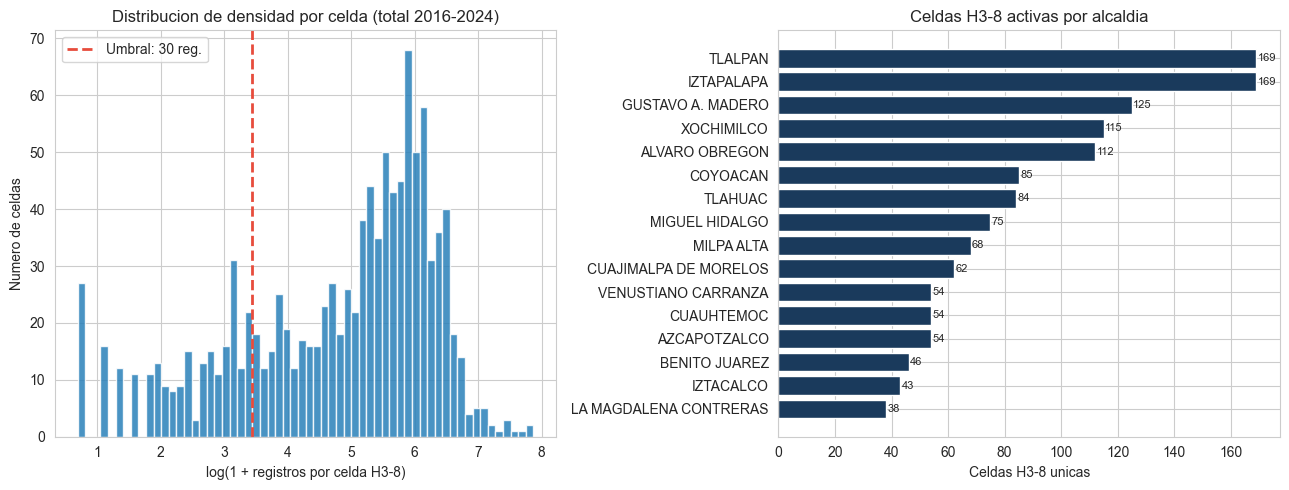

In [7]:
# Figura 09: Cobertura espacial H3-8
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: distribucion log de registros por celda
axes[0].hist(np.log1p(conteos_8.values), bins=60,
             color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].axvline(np.log1p(MIN_REGISTROS_POR_UNIDAD), color='#e74c3c',
                lw=2, ls='--', label=f'Umbral: {MIN_REGISTROS_POR_UNIDAD} reg.')
axes[0].set_xlabel('log(1 + registros por celda H3-8)')
axes[0].set_ylabel('Numero de celdas')
axes[0].set_title('Distribucion de densidad por celda (total 2016-2024)')
axes[0].legend()

# Panel derecho: celdas H3-8 por alcaldia
celdas_x_alc_sort = celdas_por_alc.sort_values()
axes[1].barh(celdas_x_alc_sort.index, celdas_x_alc_sort.values,
             color='#1a3a5c', edgecolor='white')
for i, v in enumerate(celdas_x_alc_sort.values):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=8)
axes[1].set_xlabel('Celdas H3-8 unicas')
axes[1].set_title('Celdas H3-8 activas por alcaldia')

plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/09_cobertura_h3.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Seccion 3: Definicion y Filtrado de Unidades Espacio-Temporales



  La unidad básica de análisis del pipeline es el par compuesto por una celda
  H3-8 y un año calendario. Cada una de estas unidades acumula todos los
  eventos delictivos registrados en ese hexágono durante ese periodo y
  constituye el objeto sobre el que se construirá la firma de 22 dimensiones.
  Sin embargo, no todas las unidades producen firmas estadísticamente
  confiables: aquellas con pocos registros generan proporciones altamente
  inestables que el modelo interpretaría como señal cuando en realidad son
  ruido. Esta sección define el criterio para retener únicamente las unidades
  con masa estadística suficiente y justifica cada umbral de calidad a partir
  de la estructura del propio dataset.


In [8]:
# ============================================================
# 3.1 DEFINICION DE UNIDADES Y ANALISIS PRE-FILTRADO
# ============================================================
n_total_por_unidad = df.groupby(['h3_8', 'año_hecho']).size()
n_unidades_total   = len(n_total_por_unidad)
n_celdas_total     = n_total_por_unidad.index.get_level_values('h3_8').nunique()

print('=== UNIDADES ESPACIO-TEMPORALES (PRE-FILTRADO) ===')
print(f'  Celdas H3-8 con al menos 1 registro:    {n_celdas_total:,}')
print(f'  Unidades (celda, año) totales:           {n_unidades_total:,}')
print(f'  Cobertura maxima (celdas x 9 años):      {n_celdas_total * 9:,}')
print(f'  Llenado efectivo:                        {n_unidades_total/(n_celdas_total*9)*100:.1f}%')
print(f'\n  Registros por unidad (estadisticos):')
for label, val in [('Media', n_total_por_unidad.mean()),
                   ('Mediana', n_total_por_unidad.median()),
                   ('P10', n_total_por_unidad.quantile(0.10)),
                   ('P90', n_total_por_unidad.quantile(0.90)),
                   ('Max', n_total_por_unidad.max())]:
    print(f'    {label:<10} {val:.1f}')

=== UNIDADES ESPACIO-TEMPORALES (PRE-FILTRADO) ===
  Celdas H3-8 con al menos 1 registro:    1,114
  Unidades (celda, año) totales:           9,120
  Cobertura maxima (celdas x 9 años):      10,026
  Llenado efectivo:                        91.0%

  Registros por unidad (estadisticos):
    Media      31.0
    Mediana    22.0
    P10        2.0
    P90        68.0
    Max        733.0


### 3.2 Determinacion Adaptativa del Umbral de Calidad (Filtro 1)

  El umbral mínimo de registros por unidad no se fijó a priori sino que se
  derivó de la estructura del dataset mediante dos métodos complementarios. El
  primero aplica el algoritmo Kneedle sobre la curva de retención de unidades
  en escala logarítmica: se construye la función que relaciona cada umbral
  candidato con el número de unidades que lo superan, se normaliza en escala
  log para el eje del umbral y se identifica el punto de máxima distancia
  perpendicular a la diagonal, que corresponde al umbral donde la relación
  entre calidad estadística ganada y unidades perdidas es óptima. El segundo
  método calcula la varianza media de las proporciones del crime mix para cada
  umbral candidato e identifica el primer valor que captura el 75% de la
  reducción total de varianza, es decir, el punto donde incrementar el umbral
  ya no produce mejoras sustanciales en la estabilidad de las proporciones.


Si ambos metodos convergen en el mismo umbral, ese valor es el adoptado.
Si divergen, se toma el maximo de los dos (enfoque conservador: se prefiere perder
algunas unidades antes que incorporar proporciones con alta varianza estadistica).
La coincidencia o discrepancia con el valor inicial (30) es una validacion empirica
de la eleccion original.

**Nota de implementacion:** La curva de retencion de este dataset exhibe una caida muy
pronunciada en los primeros valores de umbral (muchas unidades tienen 1-5 registros),
lo que colapsa el codo hacia el origen si se usa escala lineal en ambos ejes. Se aplica
**escala logaritmica en el eje del umbral** antes de normalizar, lo que distribuye mejor
la densidad de puntos en la zona de transicion y permite que el codo aparezca en el
interior de la curva. El mismo tratamiento se aplica a la curva de varianza.


In [9]:
# ============================================================
# 3.2 CALCULO DEL UMBRAL ADAPTATIVO (Kneedle con escala logaritmica)
# ============================================================

# --- METODO 1: Kneedle sobre la curva de retencion (eje X en log) ---
# La distribucion de registros por unidad es log-normal: muchas unidades
# tienen pocos registros, pocas tienen muchos. Normalizar el eje del umbral
# en escala logaritmica redistribuye los puntos y evita el colapso del codo
# hacia el origen que ocurre con escala lineal.
_thresholds = np.arange(1, 201)
_units_ret  = np.array([(n_total_por_unidad >= t).sum() for t in _thresholds])

# Normalizacion: log(t) en X, unidades retenidas en Y
_x_n = (np.log(_thresholds) - np.log(_thresholds[0])) / \
       (np.log(_thresholds[-1]) - np.log(_thresholds[0]))
_y_n = (_units_ret - _units_ret[-1]) / (_units_ret[0] - _units_ret[-1])

# Codo: punto de maxima distancia sobre la diagonal (Kneedle, 2011)
_kneedle_ret = _y_n + _x_n - 1
UMBRAL_KNEEDLE = int(_thresholds[np.argmax(_kneedle_ret)])

print(f'Metodo 1 — Kneedle log (curva retencion): {UMBRAL_KNEEDLE} registros')

# --- METODO 2: Reduccion acumulada de varianza al 75% ---
# Se construye el crime mix sin filtrar y se mide cuanta varianza de
# proporciones queda en las unidades con >= t registros.
# El umbral es el mas pequeno t que captura el 75% de la reduccion
# total de varianza (rendimientos decrecientes del 25% restante).
# El 75% es un criterio conservador: deja margen para unidades con
# varianza algo mayor sin exigir estabilidad perfecta.
_crime_all = (
    df.groupby(['h3_8', 'año_hecho', 'categoria_delito'])
    .size()
    .unstack(level='categoria_delito', fill_value=0)
    .reindex(columns=TOP_10_CATEGORIAS, fill_value=0)
)
_mix_all = _crime_all.div(_crime_all.sum(axis=1), axis=0)

_thresholds_var = np.arange(5, 151, 5)
_variances = []
for t in _thresholds_var:
    _idx = n_total_por_unidad[n_total_por_unidad >= t].index
    _sub = _mix_all.loc[_mix_all.index.isin(_idx)]
    _variances.append(_sub.var(axis=0).mean())
_var_arr = np.array(_variances)

# Reduccion acumulada: cuanto de la reduccion total de varianza se captura
_total_red = _var_arr[0] - _var_arr[-1]
_marginal  = -np.diff(_var_arr)            # positivo: varianza cae al subir t
_cumul_pct = np.cumsum(_marginal) / _total_red  # fraccion acumulada capturada
_idx_75 = int(np.argmax(_cumul_pct >= 0.75))    # primer t con >=75% de reduccion
UMBRAL_VARIANZA = int(_thresholds_var[_idx_75 + 1])

print(f'Metodo 2 — Reduccion varianza 75%:        {UMBRAL_VARIANZA} registros')
print(f'  (varianza residual tras umbral: {_var_arr[_idx_75+1]:.5f}')
print(f'   varianza inicial (t=5):        {_var_arr[0]:.5f})')

Metodo 1 — Kneedle log (curva retencion): 9 registros
Metodo 2 — Reduccion varianza 75%:        10 registros
  (varianza residual tras umbral: 0.00705
   varianza inicial (t=5):        0.00831)


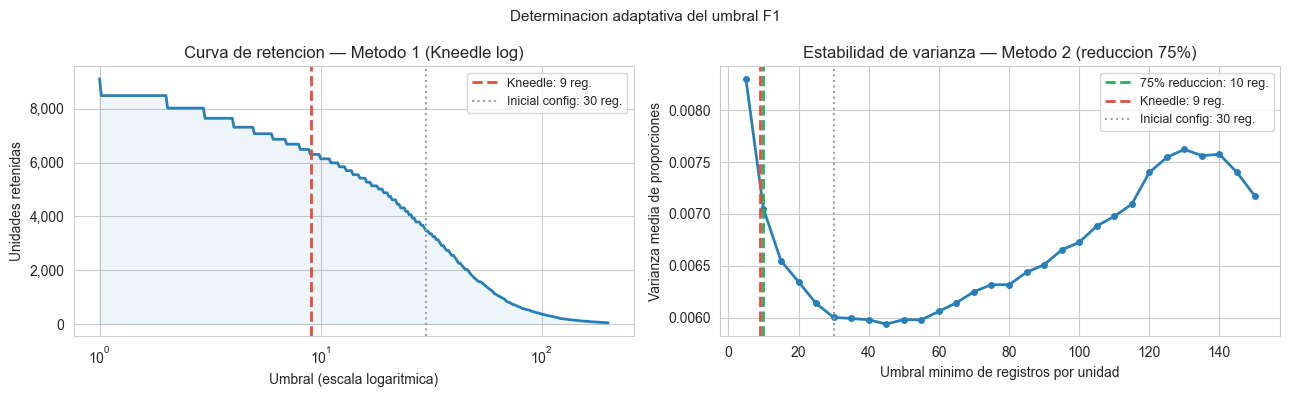


=== TABLA COMPARATIVA DE UMBRALES ===
  Umbral   Unidades   Celdas   % registros
---------------------------------------------
       9      6,490      830         96.7% <-- M1
      10      6,303      808         96.1% <-- M2
      15      5,551      743         92.9%
      20      4,881      691         88.9%
      25      4,187      641         83.5%
      30      3,564      594         77.6% <-- config inicial
      40      2,552      509         65.3%
      50      1,733      424         52.5%

  DECISION FINAL DEL UMBRAL ADAPTATIVO (F1)
  Metodo 1 — Kneedle log (retencion):      9 registros
  Metodo 2 — Varianza 75% reduccion:      10 registros
  Criterio de decision:                max (enfoque conservador)
  Umbral adoptado:                        10 registros
  Umbral inicial en configuracion:        30 registros
  El umbral inicial (30) era conservador. El dato sugiere 10,
  lo que retiene mas unidades sin sacrificar calidad estadistica.


In [10]:
# ============================================================
# 3.2 VISUALIZACION Y DECISION FINAL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: curva de retencion (eje X en escala log)
_thresholds_log = np.logspace(0, np.log10(200), 300)
_units_log = np.array([(n_total_por_unidad >= t).sum() for t in _thresholds_log])
axes[0].plot(_thresholds_log, _units_log, color='#2980b9', lw=2)
axes[0].fill_between(_thresholds_log, _units_log, alpha=0.08, color='#2980b9')
axes[0].axvline(UMBRAL_KNEEDLE, color='#e74c3c', lw=2, ls='--',
                label=f'Kneedle: {UMBRAL_KNEEDLE} reg.')
axes[0].axvline(_UMBRAL_CONFIG_INICIAL, color='#95a5a6', lw=1.5, ls=':',
                label=f'Inicial config: {_UMBRAL_CONFIG_INICIAL} reg.')
axes[0].set_xscale('log')
axes[0].set_xlabel('Umbral (escala logaritmica)')
axes[0].set_ylabel('Unidades retenidas')
axes[0].set_title('Curva de retencion — Metodo 1 (Kneedle log)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].legend(fontsize=9)

# Panel derecho: curva de varianza con umbral de reduccion al 75%
axes[1].plot(_thresholds_var, _var_arr, color='#2980b9', lw=2, marker='o', ms=4)
axes[1].axvline(UMBRAL_VARIANZA, color='#27ae60', lw=2, ls='--',
                label=f'75% reduccion: {UMBRAL_VARIANZA} reg.')
axes[1].axvline(UMBRAL_KNEEDLE, color='#e74c3c', lw=2, ls='--',
                label=f'Kneedle: {UMBRAL_KNEEDLE} reg.')
axes[1].axvline(_UMBRAL_CONFIG_INICIAL, color='#95a5a6', lw=1.5, ls=':',
                label=f'Inicial config: {_UMBRAL_CONFIG_INICIAL} reg.')
axes[1].set_xlabel('Umbral minimo de registros por unidad')
axes[1].set_ylabel('Varianza media de proporciones')
axes[1].set_title('Estabilidad de varianza — Metodo 2 (reduccion 75%)')
axes[1].legend(fontsize=9)

plt.suptitle('Determinacion adaptativa del umbral F1', fontsize=11)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/10_umbral_adaptativo.png', dpi=150, bbox_inches='tight')
plt.show()

# ── TABLA COMPARATIVA: impacto de distintos umbrales ──────────────────
print('\n=== TABLA COMPARATIVA DE UMBRALES ===')
print(f'{"Umbral":>8} {"Unidades":>10} {"Celdas":>8} {"% registros":>13}')
print('-' * 45)
for t in sorted(set([10, 15, 20, 25, _UMBRAL_CONFIG_INICIAL, 40, 50,
                     UMBRAL_KNEEDLE, UMBRAL_VARIANZA])):
    _u = (n_total_por_unidad >= t).sum()
    _c = n_total_por_unidad[n_total_por_unidad >= t].index.get_level_values('h3_8').nunique()
    _r = n_total_por_unidad[n_total_por_unidad >= t].sum() / len(df) * 100
    _marker = ' <-- M1' if t == UMBRAL_KNEEDLE else (' <-- M2' if t == UMBRAL_VARIANZA else
              (f' <-- config inicial' if t == _UMBRAL_CONFIG_INICIAL else ''))
    print(f'{t:>8} {_u:>10,} {_c:>8,} {_r:>12.1f}%{_marker}')

# ── DECISION FINAL ────────────────────────────────────────────────────
# Se adopta el umbral que resulte de la convergencia de ambos metodos.
# Si divergen, se aplica criterio conservador (maximo) con la restriccion
# de que el resultado final no deje menos de 1,500 unidades (minimo
# practico para el entrenamiento del autoencoder en NB03).
_umbral_propuesto = max(UMBRAL_KNEEDLE, UMBRAL_VARIANZA)
_unidades_propuestas = (n_total_por_unidad >= _umbral_propuesto).sum()
if _unidades_propuestas < 1500:
    # El umbral adaptativo deja pocas unidades; usar el mas pequeno de los dos
    MIN_REGISTROS_POR_UNIDAD = min(UMBRAL_KNEEDLE, UMBRAL_VARIANZA)
    _criterio = 'min (umbral max deja < 1,500 unidades)'
else:
    MIN_REGISTROS_POR_UNIDAD = _umbral_propuesto
    _criterio = 'max (enfoque conservador)'

print('\n' + '=' * 55)
print('  DECISION FINAL DEL UMBRAL ADAPTATIVO (F1)')
print('=' * 55)
print(f'  Metodo 1 — Kneedle log (retencion):  {UMBRAL_KNEEDLE:>5} registros')
print(f'  Metodo 2 — Varianza 75% reduccion:   {UMBRAL_VARIANZA:>5} registros')
print(f'  Criterio de decision:                {_criterio}')
print(f'  Umbral adoptado:                     {MIN_REGISTROS_POR_UNIDAD:>5} registros')
print(f'  Umbral inicial en configuracion:     {_UMBRAL_CONFIG_INICIAL:>5} registros')
print('=' * 55)
if MIN_REGISTROS_POR_UNIDAD == _UMBRAL_CONFIG_INICIAL:
    print(f'  El umbral inicial ({_UMBRAL_CONFIG_INICIAL}) queda validado empiricamente.')
elif MIN_REGISTROS_POR_UNIDAD < _UMBRAL_CONFIG_INICIAL:
    print(f'  El umbral inicial ({_UMBRAL_CONFIG_INICIAL}) era conservador. El dato sugiere {MIN_REGISTROS_POR_UNIDAD},')
    print( '  lo que retiene mas unidades sin sacrificar calidad estadistica.')
else:
    print(f'  El umbral inicial ({_UMBRAL_CONFIG_INICIAL}) era insuficiente. El dato sugiere {MIN_REGISTROS_POR_UNIDAD},')
    print( '  que elimina unidades con proporciones aun inestables.')

### 3.3 Filtros


  Se aplican dos filtros en cascada. El primero descarta todas las unidades con
  menos de 10 registros. El segundo elimina las celdas que, tras el primer
  filtro, presentan datos en menos de tres años distintos, ya que una celda con
  uno o dos puntos temporales no tiene trayectoria analizable con las técnicas
  de detección de cambio previstas en etapas posteriores del pipeline.

In [11]:
# ============================================================
# 3.3 FILTRO 1: UMBRAL MINIMO DE REGISTROS POR UNIDAD
# ============================================================
unidades_f1 = n_total_por_unidad[n_total_por_unidad >= MIN_REGISTROS_POR_UNIDAD]
n_unidades_f1 = len(unidades_f1)
cobertura_f1  = unidades_f1.sum() / len(df) * 100

print(f'=== FILTRO 1: min registros >= {MIN_REGISTROS_POR_UNIDAD} ===')
print(f'  Unidades antes:  {n_unidades_total:>8,}')
print(f'  Unidades despues:{n_unidades_f1:>8,}  ({n_unidades_f1/n_unidades_total*100:.1f}% retenidas)')
print(f'  Registros cubiertos: {cobertura_f1:.1f}% del total')

# ============================================================
# 3.3 FILTRO 2: MINIMO DE AÑOS ACTIVOS POR CELDA
# ============================================================
anos_por_celda = unidades_f1.reset_index().groupby('h3_8').size()
celdas_validas = anos_por_celda[anos_por_celda >= MIN_ANOS_ACTIVOS].index
n_celdas_finales = len(celdas_validas)

unidades_finales = unidades_f1[
    unidades_f1.index.get_level_values('h3_8').isin(celdas_validas)
]
n_unidades_finales = len(unidades_finales)

print(f'\n=== FILTRO 2: min años activos >= {MIN_ANOS_ACTIVOS} ===')
print(f'  Celdas tras Filtro 1:   {len(anos_por_celda):>6,}')
print(f'  Celdas validas:         {n_celdas_finales:>6,}  ({n_celdas_finales/len(anos_por_celda)*100:.1f}% retenidas)')
print(f'  Unidades finales:       {n_unidades_finales:>6,}')

print(f'\n=== DISTRIBUCION DE AÑOS ACTIVOS POR CELDA ===')
dist_anos = anos_por_celda.value_counts().sort_index()
for anos, cnt in dist_anos.items():
    marca = '  <-- ELIMINADAS' if anos < MIN_ANOS_ACTIVOS else ''
    print(f'  {anos} año(s): {cnt:>5,} celdas{marca}')

=== FILTRO 1: min registros >= 10 ===
  Unidades antes:     9,120
  Unidades despues:   6,303  (69.1% retenidas)
  Registros cubiertos: 96.1% del total

=== FILTRO 2: min años activos >= 3 ===
  Celdas tras Filtro 1:      808
  Celdas validas:            748  (92.6% retenidas)
  Unidades finales:        6,224

=== DISTRIBUCION DE AÑOS ACTIVOS POR CELDA ===
  1 año(s):    41 celdas  <-- ELIMINADAS
  2 año(s):    19 celdas  <-- ELIMINADAS
  3 año(s):    21 celdas
  4 año(s):    19 celdas
  5 año(s):    20 celdas
  6 año(s):    30 celdas
  7 año(s):    33 celdas
  8 año(s):    51 celdas
  9 año(s):   574 celdas


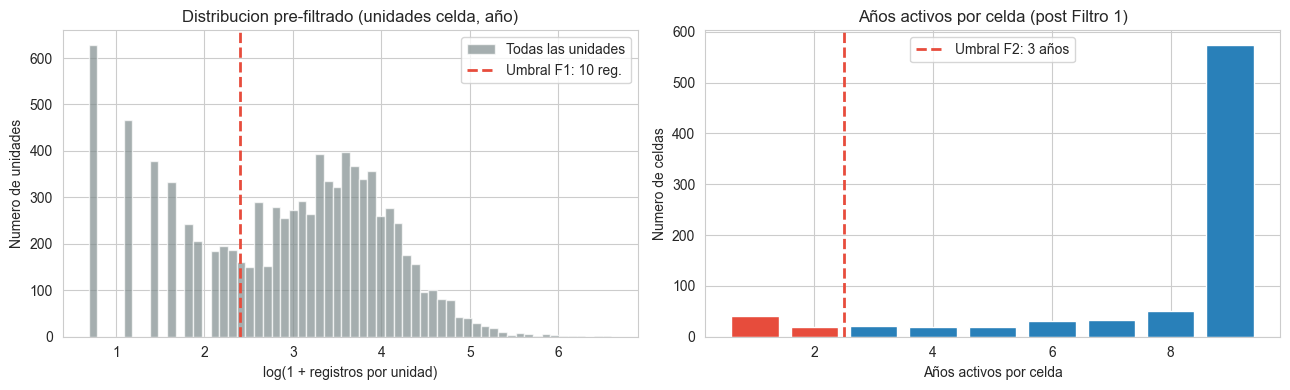

Resumen del filtrado en cascada:
  Unidades iniciales:     9,120
  Tras Filtro 1:          6,303  (-2,817)
  Tras Filtro 2:          6,224  (-79)
  Celdas finales:           748


In [12]:
# Figura 10: Impacto del filtrado
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: distribucion log de registros/unidad con umbral
vals_log = np.log1p(n_total_por_unidad.values)
axes[0].hist(vals_log, bins=60, color='#7f8c8d', edgecolor='white', alpha=0.7,
             label='Todas las unidades')
axes[0].axvline(np.log1p(MIN_REGISTROS_POR_UNIDAD), color='#e74c3c',
                lw=2, ls='--', label=f'Umbral F1: {MIN_REGISTROS_POR_UNIDAD} reg.')
axes[0].set_xlabel('log(1 + registros por unidad)')
axes[0].set_ylabel('Numero de unidades')
axes[0].set_title('Distribucion pre-filtrado (unidades celda, año)')
axes[0].legend()

# Panel derecho: años activos por celda (post Filtro 1)
colores = ['#e74c3c' if a < MIN_ANOS_ACTIVOS else '#2980b9'
           for a in dist_anos.index]
axes[1].bar(dist_anos.index, dist_anos.values, color=colores, edgecolor='white')
axes[1].axvline(MIN_ANOS_ACTIVOS - 0.5, color='#e74c3c', lw=2, ls='--',
                label=f'Umbral F2: {MIN_ANOS_ACTIVOS} años')
axes[1].set_xlabel('Años activos por celda')
axes[1].set_ylabel('Numero de celdas')
axes[1].set_title('Años activos por celda (post Filtro 1)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/11_filtrado_unidades.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Resumen del filtrado en cascada:')
print(f'  Unidades iniciales:  {n_unidades_total:>8,}')
print(f'  Tras Filtro 1:       {n_unidades_f1:>8,}  (-{n_unidades_total-n_unidades_f1:,})')
print(f'  Tras Filtro 2:       {n_unidades_finales:>8,}  (-{n_unidades_f1-n_unidades_finales:,})')
print(f'  Celdas finales:      {n_celdas_finales:>8,}')

### 3.4 Analisis Comparativo H3-8 vs H3-7



  Se construyó el conjunto equivalente de unidades espacio-temporales para la
  resolución H3-7 aplicando los mismos filtros de calidad, con el objetivo de
  validar empíricamente la elección de H3-8 como resolución primaria mediante
  una comparación directa de indicadores. 

In [13]:
# ============================================================
# 3.4 COMPARATIVA H3-7 vs H3-8
# ============================================================
n_total_h7    = df.groupby(['h3_7', 'año_hecho']).size()
unidades_h7_f1 = n_total_h7[n_total_h7 >= MIN_REGISTROS_POR_UNIDAD]
anos_h7        = unidades_h7_f1.reset_index().groupby('h3_7').size()
celdas_h7_val  = anos_h7[anos_h7 >= MIN_ANOS_ACTIVOS]
unidades_h7_fin = unidades_h7_f1[
    unidades_h7_f1.index.get_level_values('h3_7').isin(celdas_h7_val.index)
]

comparativa = pd.DataFrame({
    'Resolucion':             ['H3-7', 'H3-8'],
    'Area_km2':               [H3_7_AREA_KM2, H3_8_AREA_KM2],
    'Celdas_activas_raw':     [
        n_total_h7.index.get_level_values('h3_7').nunique(),
        n_celdas_total
    ],
    'Celdas_tras_filtros':    [len(celdas_h7_val), n_celdas_finales],
    'Unidades_finales':       [len(unidades_h7_fin), n_unidades_finales],
    'Media_reg_por_unidad':   [
        round(n_total_h7.mean(), 1),
        round(n_total_por_unidad.mean(), 1)
    ],
    'Mediana_reg_por_unidad': [
        round(n_total_h7.median(), 0),
        round(n_total_por_unidad.median(), 0)
    ],
})

print('=== COMPARATIVA DE RESOLUCIONES H3 ===')
display(comparativa.set_index('Resolucion'))
print('\nDecision: se procede con H3-8 como resolucion primaria.')
print('Mayor granularidad espacial con dispersion controlada por los filtros de calidad.')

=== COMPARATIVA DE RESOLUCIONES H3 ===


,Area_km2,Celdas_activas_raw,Celdas_tras_filtros,Unidades_finales,Media_reg_por_unidad,Mediana_reg_por_unidad
Resolucion,,,,,,
H3-7,5.1612,196,171,1464,166.0,94.0
H3-8,0.7372,1114,748,6224,31.0,22.0



Decision: se procede con H3-8 como resolucion primaria.
Mayor granularidad espacial con dispersion controlada por los filtros de calidad.


---

## Seccion 4: Construccion de la Firma Multi-Vista


  Cada unidad espacio-temporal se representa mediante un vector de 22
  dimensiones estructurado en cuatro vistas complementarias. La decisión de
  construir una representación multivista responde a que ninguna dimensión
  aislada captura por sí sola el perfil criminológico de una zona: el tipo de
  delito que predomina, los momentos del día en que se concentra, la
  distribución entre días laborables y fin de semana, y la intensidad relativa
  del fenómeno son señales ortogonales que el modelo necesita recibir de forma
  simultánea. Las vistas proporcionales se construyen dividiendo los conteos de
  cada categoría por el total de la unidad, de modo que cada una suma
  exactamente 1.0 por fila y el vector capture el patrón relativo del crimen
  con independencia del volumen absoluto, que queda reservado para la vista de
  intensidad.

#### 4.1 Vista de Crime Mix


  Se calculó la proporción de cada una de las diez categorías delictivas sobre
  el total de registros de cada unidad espacio-temporal. El resultado es una
  vista de 10 dimensiones donde cada valor representa la fracción del crimen de
  esa zona en ese año que corresponde a ese tipo de delito. Los códigos cortos
  asignados a cada columna, como cm_transeunte o cm_vehiculo, facilitan la
  lectura del vector en etapas posteriores.

In [14]:
# ============================================================
# 4.1 VISTA DE CRIME MIX (10 dimensiones)
# Proporciones de cada categoria sobre el total de la unidad.
# Captura la COMPOSICION CUALITATIVA del crimen: si una zona
# es predominantemente de robo a transeunte vs. vehiculo, etc.
# ============================================================
crime_counts = (
    df.groupby(['h3_8', 'año_hecho', 'categoria_delito'])
    .size()
    .unstack(level='categoria_delito', fill_value=0)
    .reindex(columns=TOP_10_CATEGORIAS, fill_value=0)
)
crime_mix = crime_counts.div(crime_counts.sum(axis=1), axis=0)
crime_mix.columns = [CAT_CODES[c] for c in crime_mix.columns]
crime_mix = crime_mix.loc[crime_mix.index.isin(unidades_finales.index)]

# Verificacion: cada fila debe sumar ~1.0
sumas = crime_mix.sum(axis=1)
print(f'Vista crime_mix: {crime_mix.shape}')
print(f'  Columnas: {list(crime_mix.columns)}')
print(f'  Suma de proporciones por fila: min={sumas.min():.4f}, max={sumas.max():.4f}')

print(f'\nProporcion media de cada categoria (todas las unidades):')
for col, val in crime_mix.mean().sort_values(ascending=False).items():
    print(f'  {col:<20} {val:.3f}')

Vista crime_mix: (6224, 10)
  Columnas: ['cm_transeunte', 'cm_vehiculo', 'cm_negocio', 'cm_repartidor', 'cm_metro', 'cm_violacion', 'cm_homicidio', 'cm_microbus', 'cm_lesiones', 'cm_casa']
  Suma de proporciones por fila: min=1.0000, max=1.0000

Proporcion media de cada categoria (todas las unidades):
  cm_vehiculo          0.343
  cm_transeunte        0.332
  cm_negocio           0.099
  cm_repartidor        0.058
  cm_violacion         0.050
  cm_homicidio         0.035
  cm_metro             0.024
  cm_microbus          0.023
  cm_lesiones          0.020
  cm_casa              0.017


#### 4.2 Vista de perfil horario


  Se calculó la proporción de registros de cada unidad correspondiente a cada
  una de las cuatro franjas horarias definidas en el Notebook 1: MADRUGADA,
  MAÑANA, TARDE y NOCHE. Esta vista captura el ritmo diario del crimen en cada
  zona, independientemente de su volumen total. 

In [15]:
# ============================================================
# 4.2 VISTA DE PERFIL HORARIO (4 dimensiones)
# Proporciones por franja horaria (MADRUGADA, MANANA, TARDE, NOCHE).
# Captura el RITMO DIARIO: si el crimen se concentra de noche,
# durante el dia, etc.
# ============================================================
hourly_counts = (
    df.groupby(['h3_8', 'año_hecho', 'franja_horaria'])
    .size()
    .unstack(level='franja_horaria', fill_value=0)
    .reindex(columns=FRANJAS, fill_value=0)
)
hourly_profile = hourly_counts.div(hourly_counts.sum(axis=1), axis=0)
hourly_profile.columns = [f'hr_{f.lower()}' for f in FRANJAS]
hourly_profile = hourly_profile.loc[hourly_profile.index.isin(unidades_finales.index)]

sumas = hourly_profile.sum(axis=1)
print(f'Vista hourly_profile: {hourly_profile.shape}')
print(f'  Columnas: {list(hourly_profile.columns)}')
print(f'  Suma proporciones: min={sumas.min():.4f}, max={sumas.max():.4f}')
print(f'\nPerfil horario medio global:')
for col, val in hourly_profile.mean().items():
    print(f'  {col:<18} {val:.3f}')

Vista hourly_profile: (6224, 4)
  Columnas: ['hr_madrugada', 'hr_manana', 'hr_tarde', 'hr_noche']
  Suma proporciones: min=1.0000, max=1.0000

Perfil horario medio global:
  hr_madrugada       0.135
  hr_manana          0.237
  hr_tarde           0.289
  hr_noche           0.339


#### 4.3 Vista de perfil semanal

  Se calculó la proporción de registros de cada unidad por día de la semana,
  codificado de 0 para lunes a 6 para domingo. Esta vista de siete dimensiones
  captura el ritmo semanal del crimen y complementa al perfil horario añadiendo
  una escala temporal distinta.

In [16]:
# ============================================================
# 4.3 VISTA DE PERFIL SEMANAL (7 dimensiones)
# Proporciones por dia de la semana (0=Lunes, 6=Domingo).
# Captura el RITMO SEMANAL: concentracion en dias laborales
# vs. fin de semana, que difieren significativamente por
# tipo de delito (e.g., robos a negocio vs. riñas nocturnas).
# ============================================================
weekly_counts = (
    df.groupby(['h3_8', 'año_hecho', 'dia_semana_num'])
    .size()
    .unstack(level='dia_semana_num', fill_value=0)
    .reindex(columns=DIAS_SEMANA, fill_value=0)
)
weekly_profile = weekly_counts.div(weekly_counts.sum(axis=1), axis=0)
weekly_profile.columns = [f'ds_{d}' for d in DIAS_SEMANA]
weekly_profile = weekly_profile.loc[weekly_profile.index.isin(unidades_finales.index)]

sumas = weekly_profile.sum(axis=1)
print(f'Vista weekly_profile: {weekly_profile.shape}')
print(f'  Columnas: {list(weekly_profile.columns)}')
print(f'  Suma proporciones: min={sumas.min():.4f}, max={sumas.max():.4f}')
print(f'\nPerfil semanal medio global:')
dias_nombres = {0:'Lun',1:'Mar',2:'Mie',3:'Jue',4:'Vie',5:'Sab',6:'Dom'}
for col, val in weekly_profile.mean().items():
    d = int(col.split('_')[1])
    print(f'  {col} ({dias_nombres[d]}): {val:.3f}')

Vista weekly_profile: (6224, 7)
  Columnas: ['ds_0', 'ds_1', 'ds_2', 'ds_3', 'ds_4', 'ds_5', 'ds_6']
  Suma proporciones: min=1.0000, max=1.0000

Perfil semanal medio global:
  ds_0 (Lun): 0.146
  ds_1 (Mar): 0.148
  ds_2 (Mie): 0.149
  ds_3 (Jue): 0.151
  ds_4 (Vie): 0.152
  ds_5 (Sab): 0.136
  ds_6 (Dom): 0.118


#### 4.4 Vista de intensidad

  Se construyó una única dimensión de intensidad a partir del logaritmo natural
  más uno del conteo total de registros por unidad, es decir, log_n = 
  log1p(n_total). La transformación logarítmica estabiliza la distribución de
  frecuencias de crimen, que sigue típicamente una distribución log-normal en
  contextos urbanos. Se descartó la densidad por kilómetro cuadrado como
  variable alternativa porque la isometría de las celdas H3-8, con variación de
  área menor al 2% entre celdas, hace que esa variable sea una transformación
  lineal de n_total con una correlación observada de r = 0.89, introduciendo
  redundancia sin aportar información adicional.

In [17]:
# ============================================================
# 4.4 VISTA DE INTENSIDAD (1 dimension)
#
# log_n: log1p del conteo total de la unidad.
#   La transformacion logaritmica estabiliza la distribucion
#   de frecuencias de crimen, tipicamente log-normal en contextos
#   urbanos (Sherman et al., 1989).
#
# Nota: densidad_km2 = n_total / H3_8_AREA_KM2 se descarta porque
#   las celdas H3-8 son isometricas (~0.737 km2, variacion < 2%),
#   lo que hace que densidad_km2 sea una transformacion lineal de
#   n_total y, por tanto, una version redundante de log_n
#   (correlacion observada r = 0.89, r2 = 0.79). Mantener ambas
#   introduce anisotropia en la dimension de intensidad.
# ============================================================
n_unidad  = df.groupby(['h3_8', 'año_hecho']).size().rename('n_total')
intensity = n_unidad.to_frame()
intensity['log_n'] = np.log1p(intensity['n_total'])
intensity = intensity[['log_n']]
intensity = intensity.loc[intensity.index.isin(unidades_finales.index)]

print(f'Vista intensity: {intensity.shape}')
print(f'  log_n | min={intensity["log_n"].min():.2f}  '
      f'max={intensity["log_n"].max():.2f}  '
      f'media={intensity["log_n"].mean():.2f}')

Vista intensity: (6224, 1)
  log_n | min=2.40  max=6.60  media=3.56


In [18]:
# ============================================================
# 4.5 ENSAMBLE DE LA MATRIZ DE FIRMAS
# pd.concat alinea automaticamente sobre el MultiIndex comun
# (h3_8, año_hecho) de las cuatro vistas.
# ============================================================
firmas_raw = pd.concat([crime_mix, hourly_profile, weekly_profile, intensity], axis=1)

# Verificaciones de integridad
assert firmas_raw.isnull().sum().sum() == 0, 'ERROR: nulos en la matriz de firmas.'
assert firmas_raw.shape[1] == DIM_TOTAL, f'ERROR: {firmas_raw.shape[1]} dims, esperado {DIM_TOTAL}'
assert len(firmas_raw) == n_unidades_finales, \
    f'ERROR: {len(firmas_raw)} filas, esperado {n_unidades_finales}'

print(f'Matriz de firmas ensamblada correctamente.')
print(f'  Forma:           {firmas_raw.shape[0]:,} unidades x {firmas_raw.shape[1]} dimensiones')
print(f'  Nulos:           {firmas_raw.isnull().sum().sum()}')
print(f'  Celdas unicas:   {firmas_raw.index.get_level_values("h3_8").nunique():,}')
print(f'  Años en indice:  {sorted(firmas_raw.index.get_level_values("año_hecho").unique())}')
print(f'\nEsquema de columnas:')
for vista, prefix in [('crime_mix', DIM_CRIME_MIX), ('hourly', DIM_HOURLY),
                      ('weekly', DIM_WEEKLY), ('intensity', DIM_INTENSITY)]:
    cols = firmas_raw.columns[
        [c.startswith('cm_') if vista=='crime_mix'
         else c.startswith('hr_') if vista=='hourly'
         else c.startswith('ds_') if vista=='weekly'
         else c in INTENSITY_COLS for c in firmas_raw.columns]
    ]
    print(f'  {vista:<12} ({prefix} dims): {list(cols)}')

Matriz de firmas ensamblada correctamente.
  Forma:           6,224 unidades x 22 dimensiones
  Nulos:           0
  Celdas unicas:   748
  Años en indice:  [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Esquema de columnas:
  crime_mix    (10 dims): ['cm_transeunte', 'cm_vehiculo', 'cm_negocio', 'cm_repartidor', 'cm_metro', 'cm_violacion', 'cm_homicidio', 'cm_microbus', 'cm_lesiones', 'cm_casa']
  hourly       (4 dims): ['hr_madrugada', 'hr_manana', 'hr_tarde', 'hr_noche']
  weekly       (7 dims): ['ds_0', 'ds_1', 'ds_2', 'ds_3', 'ds_4', 'ds_5', 'ds_6']
  intensity    (1 dims): ['log_n']


---

## Seccion 5: Normalizacion de la Matriz de Firmas


 Las cuatro vistas de la firma operan en escalas distintas. Las vistas
  proporcionales se encuentran en el intervalo [0, 1] con distribuciones
  marcadamente sesgadas hacia cero en categorías poco frecuentes, mientras que
  log_n opera en una escala absoluta diferente. Sin una normalización previa,
  las dimensiones con mayor varianza dominarían tanto el cálculo de distancias
  euclidianas durante el clustering como la propagación de gradientes durante
  el entrenamiento del autoencoder. El StandardScaler resuelve este problema
  centrando cada dimensión en media cero y escala unitaria de forma lineal,
  preservando la relación relativa entre unidades sin destruir la información
  proporcional.



  Se ajustó un StandardScaler sobre la matriz completa de 6,224 filas por 22
  columnas y se aplicó la transformación. El objeto scaler ajustado se exporta
  junto con la matriz para garantizar que cualquier transformación futura sobre
  datos nuevos utilice exactamente los mismos parámetros de media y desviación
  estándar aprendidos sobre este conjunto.



In [19]:
# ============================================================
# 5.1 APLICACION DE STANDARDSCALER
# ============================================================
scaler = StandardScaler()
arr_norm = scaler.fit_transform(firmas_raw.values)

firmas = pd.DataFrame(
    arr_norm,
    index=firmas_raw.index,
    columns=firmas_raw.columns
)

print('StandardScaler aplicado sobre la matriz completa.')
print(f'\nVerificacion por vista (media y std deben ser ~0 y ~1):')
for vista, prefix in [('crime_mix', 'cm_'), ('horario', 'hr_'),
                      ('semanal', 'ds_')]:
    cols = [c for c in firmas.columns if c.startswith(prefix)]
    m = firmas[cols].values.mean()
    s = firmas[cols].values.std()
    print(f'  {vista:<12} | media={m:+.4f}  std={s:.4f}')
_log_n_col = firmas[['log_n']]
print(f'  intensidad   | media={_log_n_col.values.mean():+.4f}  std={_log_n_col.values.std():.4f}')

StandardScaler aplicado sobre la matriz completa.

Verificacion por vista (media y std deben ser ~0 y ~1):
  crime_mix    | media=-0.0000  std=1.0000
  horario      | media=-0.0000  std=1.0000
  semanal      | media=+0.0000  std=1.0000
  intensidad   | media=-0.0000  std=1.0000


Se calculó la matriz de correlación de Pearson sobre las 22 dimensiones
  normalizadas y se identificaron todos los pares con correlación absoluta
  superior a 0.7, umbral a partir del cual dos features pueden considerarse
  redundantes para efectos del aprendizaje de representaciones.

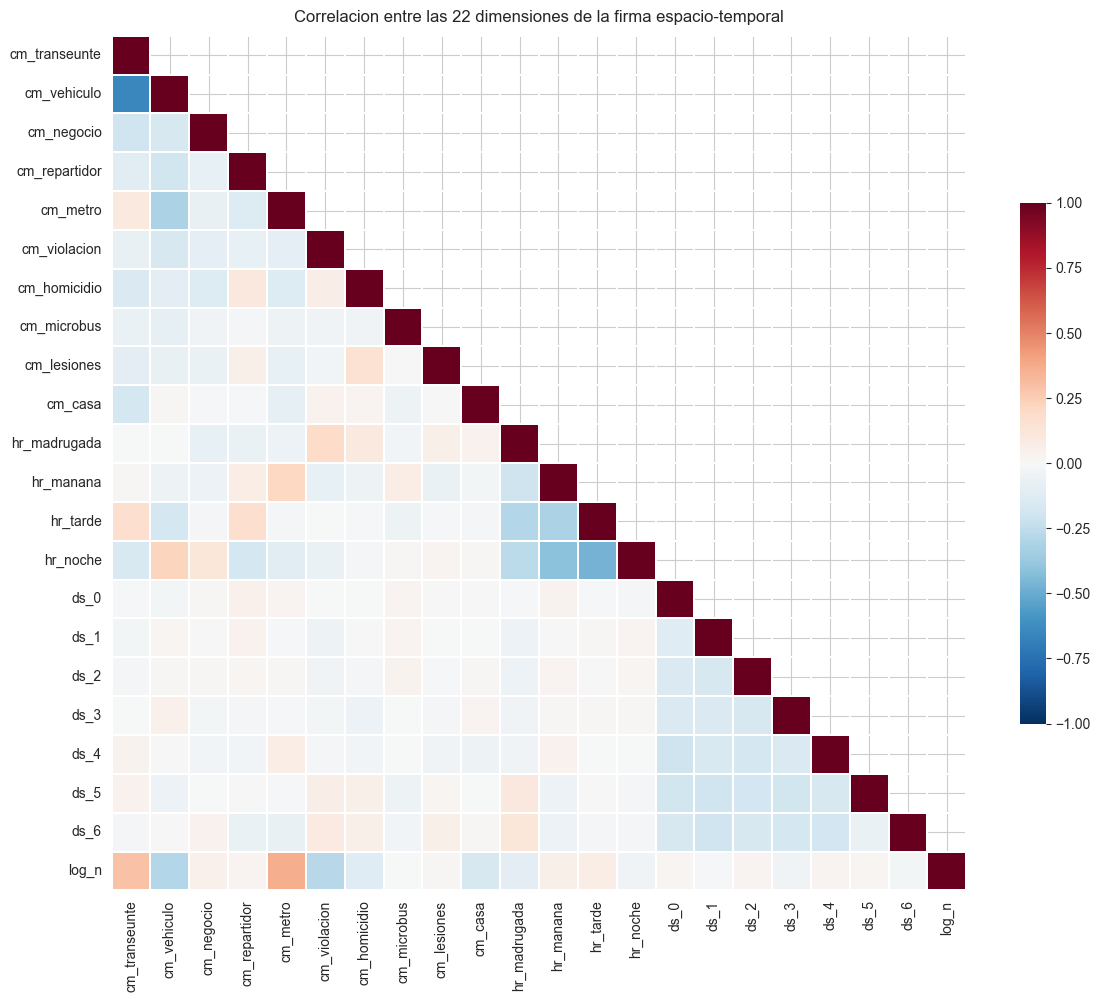

No hay pares con correlacion |r| > 0.7.


In [20]:
# ============================================================
# 5.2 ANALISIS DE CORRELACION ENTRE FEATURES
# Un heatmap de correlacion permite detectar redundancia
# entre dimensiones. Alta correlacion (|r| > 0.7) entre dos
# features sugiere que una de ellas podria eliminarse sin
# perder informacion. Esta informacion es util para decidir
# si reducir la dimensionalidad antes del autoencoder.
# ============================================================
corr = firmas.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.3,
    cbar_kws={'shrink': 0.6}, ax=ax
)
ax.set_title(f'Correlacion entre las {DIM_TOTAL} dimensiones de la firma espacio-temporal', pad=10)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/12_correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar pares de alta correlacion
corr_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pares_altos = (
    corr_tri.stack()
    .pipe(lambda s: s[s.abs() > 0.7])
    .sort_values(key=abs, ascending=False)
)
if len(pares_altos) > 0:
    print(f'Pares con |r| > 0.7 ({len(pares_altos)} pares):')
    for (c1, c2), val in pares_altos.items():
        print(f'  {c1:<22} -- {c2:<22}  r={val:.3f}')
else:
    print('No hay pares con correlacion |r| > 0.7.')

---

## Seccion 6: Almacenamiento


  Se exportan tres artefactos que constituyen el output completo de este
  notebook. El primero es la matriz de firmas normalizada en formato CSV, que
  es el input directo del autoencoder del Notebook 3. El segundo es la misma
  matriz sin normalizar, necesaria para la interpretación semántica de los
  perfiles de cluster en etapas posteriores donde los valores proporcionales
  reales son más legibles que las versiones estandarizadas. El tercero es el
  objeto StandardScaler serializado en formato pickle, indispensable para
  aplicar exactamente la misma transformación sobre nuevas unidades en
  inferencia. Adicionalmente se exporta un archivo de metadatos que documenta
  todos los parámetros del pipeline para garantizar la trazabilidad y
  reproducibilidad del proceso. Una verificación de integridad lee el archivo
  exportado y valida dimensiones y ausencia de nulos antes de cerrar el
  notebook.


In [21]:
# ============================================================
# 6.1 EXPORTACION DE LA MATRIZ NORMALIZADA
# ============================================================
firmas_export = firmas.reset_index()
RUTA_FIRMAS = f'{PATH_PROCESSED}/firmas_h3_8_anual.csv'
firmas_export.to_csv(RUTA_FIRMAS, index=False, encoding='utf-8')

tamano_mb = os.path.getsize(RUTA_FIRMAS) / 1e6
print(f'Matriz normalizada exportada.')
print(f'  Ruta:     {RUTA_FIRMAS}')
print(f'  Tamano:   {tamano_mb:.2f} MB')
print(f'  Forma:    {firmas_export.shape[0]:,} filas x {firmas_export.shape[1]} columnas')
print(f'  Columnas: h3_8, año_hecho + {DIM_TOTAL} features')

Matriz normalizada exportada.
  Ruta:     data/processed/firmas_h3_8_anual.csv
  Tamano:   2.83 MB
  Forma:    6,224 filas x 24 columnas
  Columnas: h3_8, año_hecho + 22 features


In [22]:
# ============================================================
# 6.2 EXPORTACION DE ARTEFACTOS COMPLEMENTARIOS
# ============================================================

# Matriz sin normalizar
RUTA_RAW = f'{PATH_PROCESSED}/firmas_h3_8_anual_raw.csv'
firmas_raw.reset_index().to_csv(RUTA_RAW, index=False, encoding='utf-8')
print(f'Matriz raw exportada: {RUTA_RAW}')

# StandardScaler serializado
RUTA_SCALER = f'{PATH_PROCESSED}/scaler_firmas.pkl'
with open(RUTA_SCALER, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler exportado:     {RUTA_SCALER}')

Matriz raw exportada: data/processed/firmas_h3_8_anual_raw.csv
Scaler exportado:     data/processed/scaler_firmas.pkl


In [23]:
# ============================================================
# 6.3 EXPORTACION DE METADATOS DEL PIPELINE
# ============================================================
metadata = pd.DataFrame({
    'metrica': [
        'registros_fuente',
        'resolucion_h3_primaria',
        'celdas_h3_8_activas_raw',
        'celdas_h3_8_validas',
        'unidades_celda_año_raw',
        'unidades_celda_año_validas',
        'min_registros_por_unidad',
        'min_años_activos',
        'dim_crime_mix',
        'dim_hourly_profile',
        'dim_weekly_profile',
        'dim_intensity',
        'dim_total',
        'periodo_inicio',
        'periodo_fin',
        'normalizacion',
    ],
    'valor': [
        len(df),
        H3_RES_PRIM,
        n_celdas_total,
        n_celdas_finales,
        n_unidades_total,
        n_unidades_finales,
        MIN_REGISTROS_POR_UNIDAD,
        MIN_ANOS_ACTIVOS,
        DIM_CRIME_MIX,
        DIM_HOURLY,
        DIM_WEEKLY,
        DIM_INTENSITY,
        DIM_TOTAL,
        PERIODO_INICIO,
        PERIODO_FIN,
        'StandardScaler',
    ]
})

RUTA_META = f'{PATH_PROCESSED}/metadata_firmas.csv'
metadata.to_csv(RUTA_META, index=False, encoding='utf-8')
print(f'Metadatos exportados: {RUTA_META}')
display(metadata)

Metadatos exportados: data/processed/metadata_firmas.csv


,metrica,valor
0,registros_fuente,282536
1,resolucion_h3_primaria,8
2,celdas_h3_8_activas_raw,1114
3,celdas_h3_8_validas,748
4,unidades_celda_año_raw,9120
5,unidades_celda_año_validas,6224
6,min_registros_por_unidad,10
7,min_años_activos,3
8,dim_crime_mix,10
9,dim_hourly_profile,4


In [24]:
# ============================================================
# VERIFICACION DE INTEGRIDAD FINAL
# ============================================================
df_ver = pd.read_csv(RUTA_FIRMAS)
assert df_ver.shape == firmas_export.shape, 'ERROR: dimensiones no coinciden.'
assert df_ver.isnull().sum().sum() == 0,    'ERROR: nulos en archivo exportado.'

print('Verificacion de integridad superada.')
print(f'  Registros leidos:  {len(df_ver):,}')
print(f'  Columnas leidas:   {df_ver.shape[1]}')
print(f'\nMuestra del archivo exportado:')
display(df_ver.head(3))

Verificacion de integridad superada.
  Registros leidos:  6,224
  Columnas leidas:   24

Muestra del archivo exportado:


,h3_8,año_hecho,cm_transeunte,cm_vehiculo,cm_negocio,cm_repartidor,cm_metro,cm_violacion,cm_homicidio,cm_microbus,...,hr_tarde,hr_noche,ds_0,ds_1,ds_2,ds_3,ds_4,ds_5,ds_6,log_n
0,88499516d9fffff,2016,-0.925698,1.426717,-0.865983,0.443383,-0.341277,0.138305,-0.135734,-0.610621,...,-0.037979,-0.235114,0.381658,1.590926,-0.503402,0.719261,-0.535627,-1.570983,-0.062732,0.028786
1,88499516d9fffff,2017,-1.118934,0.657866,0.057724,0.725481,-0.341277,-0.896776,0.769786,1.221542,...,-1.530370,1.389987,-0.622048,0.355426,-0.660452,0.316920,-0.202715,-0.475435,1.348558,-0.253053
2,88499516d9fffff,2018,-1.349245,0.763002,-0.931558,0.559649,-0.341277,0.366986,0.787763,0.625024,...,-0.574777,0.546826,0.254123,-0.802229,-0.137505,-0.501795,-0.180133,1.413616,-0.032356,0.338990


---
## Conclusiones del Notebook 02
  Este notebook transforma 282,536 eventos delictivos puntuales en una matriz
  de 6,224 representaciones vectoriales densas que codifican el perfil
  criminológico de 748 zonas urbanas de la CDMX a lo largo de nueve periodos
  anuales. La reducción desde las 1,114 celdas activas hasta las 748 válidas no es una pérdida de cobertura sino una garantía de calidad estadística: las
  366 celdas descartadas por los filtros adaptativos producirían firmas cuyas
  proporciones reflejarían varianza muestral y no patrones territoriales reales. El umbral de 10 registros mínimos por unidad, derivado directamente
  de los datos mediante el algoritmo Kneedle en escala logarítmica, resultó más permisivo que el valor inicial de 30 sin sacrificar estabilidad, reteniendo el 96.1% de los registros totales.

  La decisión de representar cada unidad mediante una firma multivista de 22
  dimensiones responde a una premisa criminológica concreta: el perfil de una
  zona no queda capturado por ninguna dimensión aislada. El análisis de
  correlación sobre la matriz normalizada confirma que ningún par de features
  supera el umbral de redundancia de 0.7, lo que valida que las cuatro vistas
  aportan señal independiente.

  La elección de H3-8 como unidad espacial se justificó comparativamente frente a H3-7: con 5.16 km² por celda, la resolución más gruesa promedia dinámicas heterogéneas en una sola firma y produce únicamente 1,464 unidades frente a las 6,224 de H3-8, reduciendo la capacidad del modelo para detectar variación intraurbana. Que los clusters del Notebook 4 muestren coherencia geográfica sin haber utilizado coordenadas como features es la validación más sólida de que H3-8 captura la escala espacial correcta para el fenómeno estudiado. La matriz firmas_h3_8_anual.csv, junto con su versión cruda y el scaler serializado, constituye el artefacto central del pipeline sobre el que se construirán todas las representaciones y análisis de los notebooks siguientes.